In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# prevent overfitting
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

training_set = train_datagen.flow_from_directory('dataset/training_set',
                                                 target_size = (64, 64),
                                                 batch_size = 32,
                                                 class_mode = 'binary')

test_datagen = ImageDataGenerator(rescale = 1./255)

test_set = test_datagen.flow_from_directory('dataset/test_set',
                                            target_size = (64, 64),
                                            batch_size = 32,
                                            class_mode = 'binary')

cnn = tf.keras.models.Sequential()

cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=[64, 64, 3]))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

cnn.add(tf.keras.layers.Flatten())

cnn.add(tf.keras.layers.Dense(units=128, activation='relu'))
cnn.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

cnn.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

cnn.fit(x = training_set, validation_data = test_set, epochs = 25)

/Users/zserra/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 8000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Epoch 1/25


/Users/zserra/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/zserra/Library/Python/3.9/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5327 - loss: 0.6917

/Users/zserra/Library/Python/3.9/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.5330 - loss: 0.6915 - val_accuracy: 0.5940 - val_loss: 0.6637
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.6636 - loss: 0.6189 - val_accuracy: 0.6675 - val_loss: 0.6287
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.7039 - loss: 0.5661 - val_accuracy: 0.7385 - val_loss: 0.5339
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.7319 - loss: 0.5304 - val_accuracy: 0.7470 - val_loss: 0.5089
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.7385 - loss: 0.5238 - val_accuracy: 0.7650 - val_loss: 0.4906
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.7608 - loss: 0.4912 - val_accuracy: 0.7390 - val_loss: 0.5405
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.7718 - loss: 0.4765 - val_accuracy: 0.7720 - val_loss: 0.4732
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.7783 - loss: 0.4724 - val_accuracy: 0.

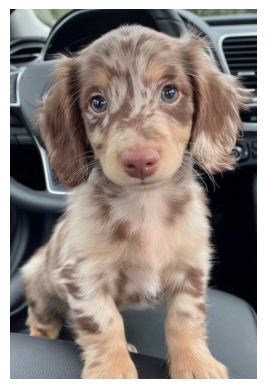

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
dog


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img_display = image.load_img('dataset/single_prediction/cat_or_dog_1.jpg')

plt.imshow(img_display)
plt.axis('off')
plt.show()

test_image = image.load_img('dataset/single_prediction/cat_or_dog_1.jpg', target_size=(64, 64))
test_image = image.img_to_array(test_image) / 255.0
test_image = np.expand_dims(test_image, axis=0)

result = cnn.predict(test_image)

if result[0][0] > 0.5:
    prediction = 'dog'
else:
    prediction = 'cat'

print(prediction)

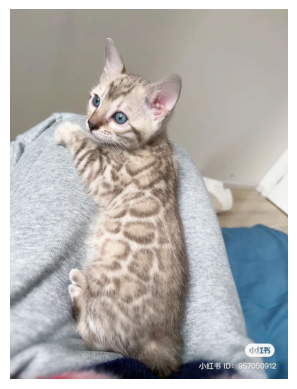

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
cat


In [3]:
img_display = image.load_img('dataset/single_prediction/cat_or_dog_2.jpg')

plt.imshow(img_display)
plt.axis('off')
plt.show()

test_image = image.load_img('dataset/single_prediction/cat_or_dog_2.jpg', target_size=(64, 64))
test_image = image.img_to_array(test_image) / 255.0
test_image = np.expand_dims(test_image, axis=0)

result = cnn.predict(test_image)

if result[0][0] > 0.5:
    prediction = 'dog'
else:
    prediction = 'cat'

print(prediction)